# Actividad 2 (laboratorio grupal). PySpark, MLlib y pipelines para clasificación

18/11/2026  
Minería de Datos Masivos  
Grado en Ciencia de Datos  
UNIR  

Integrantes del grupo:
- Alex Rubiño Fernández
- Ruben Artola Rangel
- Pablo Morales Pareja
- Santiago Martín Cabrera

## Índice

1. Configuración del entorno  
2. Análisis y visualización de datos  
3. Implementación de un ML Pipeline  
4. Evaluación del modelo y análisis de resultados  
5. Reflexión y discusión

## 1. Configuración del entorno

En esta sección se configuran las variables de entorno necesarias para PySpark en Windows (JAVA_HOME, HADOOP_HOME), se inicializa Spark y se carga el dataset proporcionado por el laboratorio "diagnostico_diabetes 1.csv". El archivo contiene información médica de pacientes para predecir si tienen diabetes.

In [15]:
import os

# Configurar variables (necesario cada vez que abres VS Code)
os.environ['JAVA_HOME'] = r"C:/Program Files/Microsoft/jdk-17.0.18.8-hotspot"
os.environ['HADOOP_HOME'] = r"C:/Users/alexr/Hadoop"

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Crear sesión Spark
spark = SparkSession.builder \
    .appName("DiabetesPrediction") \
    .config("spark.sql.warehouse.dir", "file:///C:/temp") \
    .master("local[*]") \
    .getOrCreate()

In [16]:
# Cargar el dataset proporcionado (separador ; y cabecera)
df = spark.read.csv("diagnostico_diabetes 1.csv", header=True, inferSchema=True, sep=";")

print("Dataset cargado:")
df.show(5) # Primeras 5 filas
df.printSchema() # Estructura de los datos

# Convertir la columna diabetes de VERDADERO/FALSO a 1/0 para el modelo
df = df.withColumn("diabetes_num", when(col("diabetes") == "VERDADERO", 1).otherwise(0))

# Ver la conversión
print("Conversión de diabetes a numérica:")
df.select("diabetes", "diabetes_num").show(5)

# Distribución de la variable objetivo
print("Distribución de diabetes (1=VERDADERO, 0=FALSO):")
df.groupBy("diabetes_num").count().show()

# Estadísticas básicas de las variables numéricas
print("Estadísticas básicas:")
df.describe().show()

Dataset cargado:
+---------+-----------------+-----------------+-------------------+--------+---+--------------------+----+---------+
|embarazos|glucosa en sangre|presion sanguinea|grosor piel triceps|insulina|IMC|ascendencia diabetes|edad| diabetes|
+---------+-----------------+-----------------+-------------------+--------+---+--------------------+----+---------+
|        6|              148|               72|                 35|       0|336|                 627|  50|VERDADERO|
|        1|               85|               66|                 29|       0|266|                 351|  31|    FALSO|
|        8|              183|               64|                  0|       0|233|                 672|  32|VERDADERO|
|        1|               89|               66|                 23|      94|281|                 167|  21|    FALSO|
|        0|              137|               40|                 35|     168|431|                2288|  33|VERDADERO|
+---------+-----------------+-----------------+

Estos son un poco los resultados de la configuración del entorno:

- **Total registros**: 768
- **Variables predictoras**: 8 (embarazos, glucosa, presión sanguínea, grosor piel, insulina, IMC, ascendencia diabetes, edad)
- **Variable objetivo**: diabetes (VERDADERO/FALSO)

**Distribución de clases:**
- Clase 0 (FALSO): 500 casos (65.1%)
- Clase 1 (VERDADERO): 268 casos (34.9%)

El dataset está desbalanceado con mayoría de casos negativos. Se detectan valores 0 en variables médicas que podrían indicar datos faltantes. La conversión de VERDADERO/FALSO a 1/0 se realizó correctamente.

## 2. Análisis y visualización de datos  
Para comprender mejor los datos, generamos histogramas que muestran la distribución de las variables clave y un heatmap de correlación para identificar relaciones entre las variables predictoras y la variable objetivo.

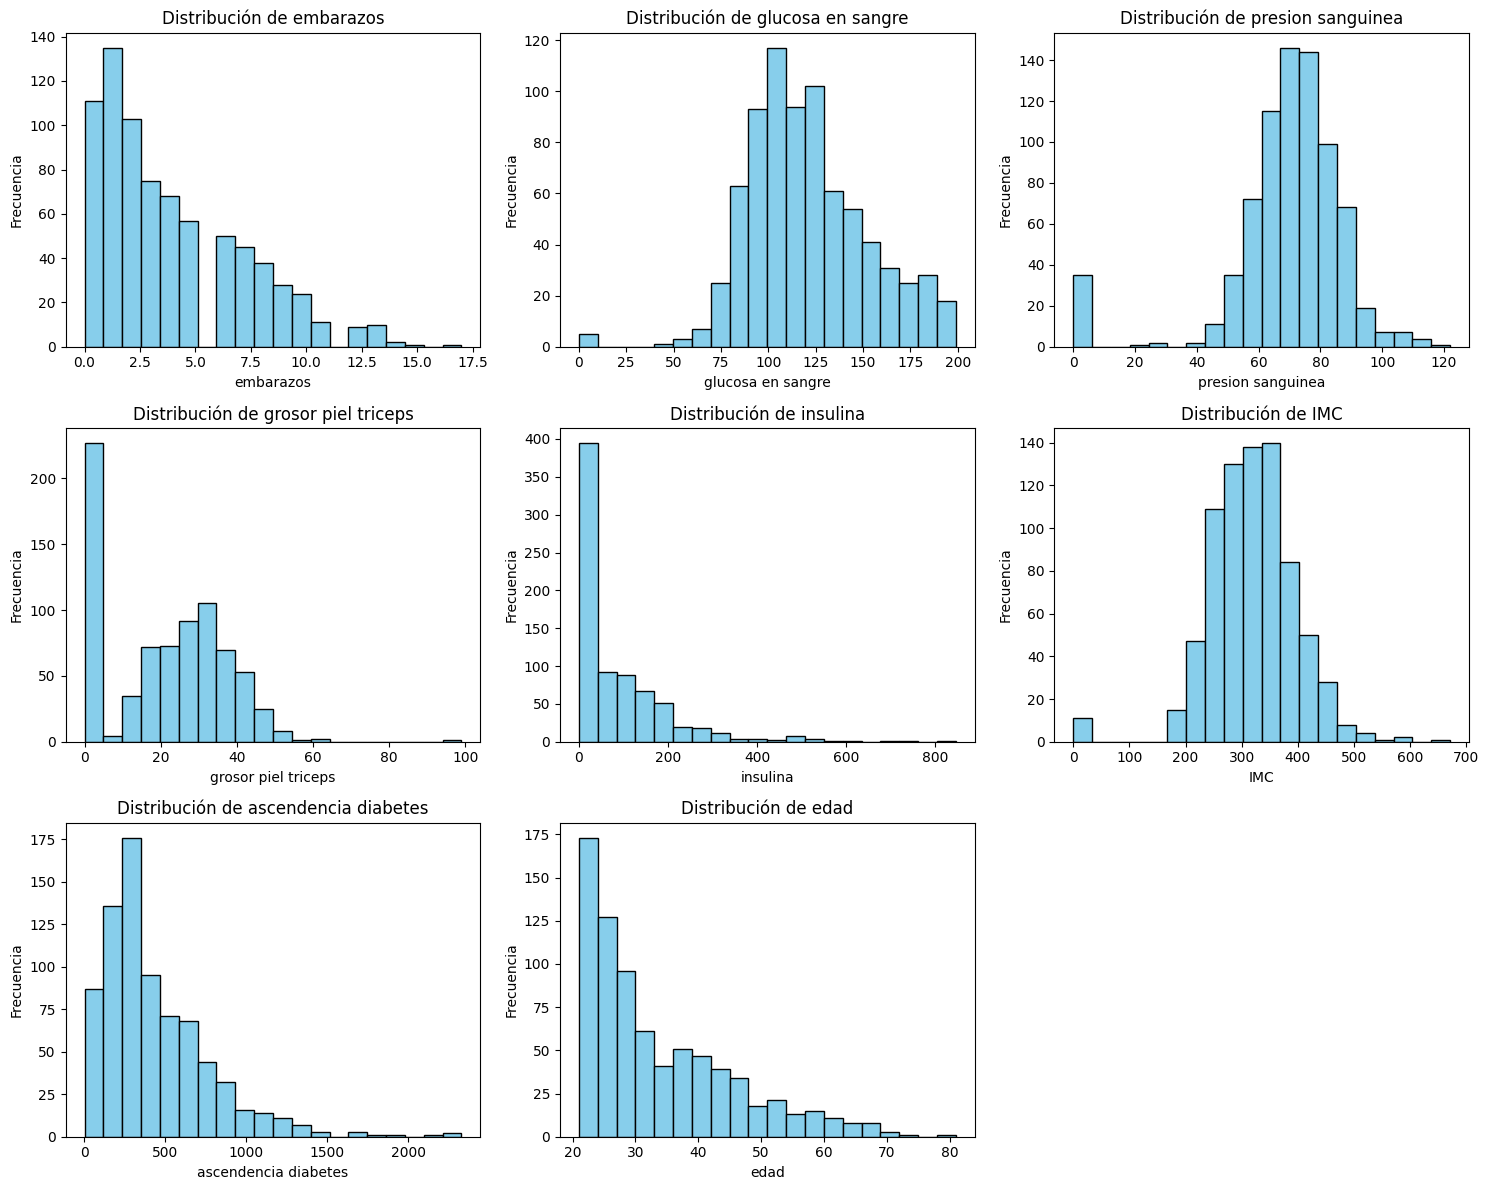

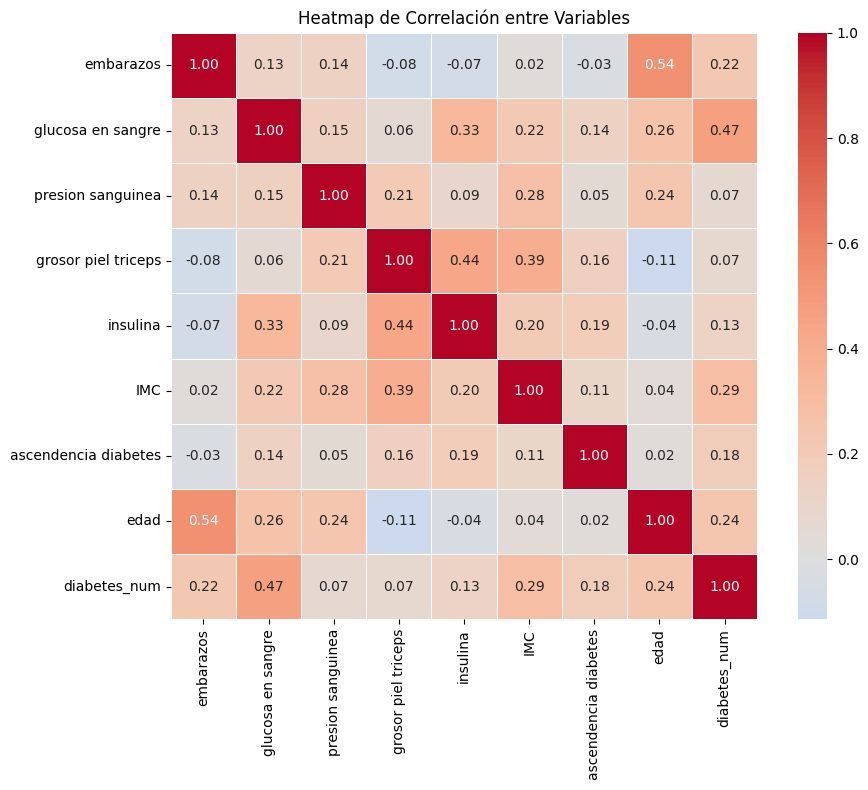

Correlaciones con la variable diabetes (diabetes_num):
  glucosa en sangre: 0.4666
  IMC: 0.2927
  edad: 0.2384
  embarazos: 0.2219
  ascendencia diabetes: 0.1796
  insulina: 0.1305
  grosor piel triceps: 0.0748
  presion sanguinea: 0.0651


In [17]:
# Convertir a Pandas para visualización (Spark no tiene matplotlib integrado)
pandas_df = df.toPandas()

# Configurar el tamaño de las figuras
plt.figure(figsize=(15, 12))

# Lista de variables a visualizar (excluyendo diabetes y diabetes_num)
variables = ['embarazos', 'glucosa en sangre', 'presion sanguinea', 
             'grosor piel triceps', 'insulina', 'IMC', 
             'ascendencia diabetes', 'edad']

# Crear histogramas para cada variable
for i, var in enumerate(variables, 1):
    plt.subplot(3, 3, i)
    plt.hist(pandas_df[var], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Heatmap de correlación
plt.figure(figsize=(10, 8))

# Seleccionar solo columnas numéricas para la correlación
columnas_correlacion = variables + ['diabetes_num']
correlacion = pandas_df[columnas_correlacion].corr()

# Crear heatmap
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)

plt.title('Heatmap de Correlación entre Variables')
plt.tight_layout()
plt.show()

# Mostrar correlaciones más relevantes con diabetes
print("Correlaciones con la variable diabetes (diabetes_num):")
corr_con_diabetes = correlacion['diabetes_num'].sort_values(ascending=False)
for var, corr in corr_con_diabetes.items():
    if var != 'diabetes_num':
        print(f"  {var}: {corr:.4f}")

Los histogramas muestran que la mayoría de las variables clínicas presentan distribuciones asimétricas. La glucosa en sangre se concentra alrededor de 120 mg/dL, mientras que la edad tiene un sesgo hacia pacientes jóvenes (20-40 años). Destaca la presencia generalizada de valores 0 en variables como insulina, glucosa y presión sanguínea, lo que probablemente indica datos faltantes en lugar de valores fisiológicos reales.

El heatmap revela que la **glucosa en sangre** es la variable con mayor correlación positiva con diabetes (0.47), seguida del IMC (0.29) y la edad (0.24). La presión sanguínea (0.07) y el grosor de piel (0.07) muestran correlaciones muy débiles, siendo poco relevantes para la predicción. Entre las variables predictoras destaca la correlación moderada entre edad y embarazos (0.54), y entre insulina y grosor de piel (0.44).

**Conclusión del análisis:** La glucosa en sangre es el factor más determinante para predecir diabetes, seguido del IMC y la edad. Se recomienda tratar los valores 0 como datos faltantes antes de entrenar el modelo, y considerar eliminar o ponderar menos las variables con baja correlación (presión sanguínea y grosor de piel) para simplificar el modelo sin perder capacidad predictiva.

## 3. Implementación de un ML Pipeline

Construimos un pipeline de ML mediante la combinación de todas las características en un solo vector con VectorAssembler, un escalado de datos para normalizarlos mediante StandardScaler y un modelo de clasificación binaria para predecir diabetes implementando una regresión logística.

In [18]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

# Columnas predictoras (todas excepto diabetes y diabetes_num)
feature_cols = ['embarazos', 'glucosa en sangre', 'presion sanguinea', 
                'grosor piel triceps', 'insulina', 'IMC', 
                'ascendencia diabetes', 'edad']

# 1. VectorAssembler: combina las features en un vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")

# 2. StandardScaler: escala los datos (sin centrar la media por los valores 0)
scaler = StandardScaler(inputCol="features_raw", outputCol="features", 
                        withStd=True, withMean=False)

# 3. LogisticRegression: modelo de clasificación
lr = LogisticRegression(labelCol="diabetes_num", featuresCol="features")

# Crear el pipeline
pipeline = Pipeline(stages=[assembler, scaler, lr])

In [20]:
# Dividir los datos en entrenamiento (80%) y prueba (20%)
train, test = df.randomSplit([0.8, 0.2], seed=42)

print(f"Entrenamiento: {train.count()} registros")
print(f"Prueba: {test.count()} registros")

# Entrenar el modelo
model = pipeline.fit(train)

Entrenamiento: 645 registros
Prueba: 123 registros


## 4. Evaluación del modelo y análisis de resultados

Evaluamos el rendimiento del modelo mediante dos métricas principales. Por un lado, el AUC-ROC, que mide la capacidad del modelo para distinguir entre pacientes con y sin diabetes. Por otro lado, la matriz de confusión, que muestra los aciertos y errores del modelo desglosados en verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

In [28]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Predicciones sobre el conjunto de prueba
predictions = model.transform(test)

# Calculo AUC-ROC
evaluator = BinaryClassificationEvaluator(labelCol="diabetes_num", 
                                           metricName="areaUnderROC")
auc = evaluator.evaluate(predictions)

print(f"AUC-ROC: {auc:.4f}")

AUC-ROC: 0.8622


In [29]:
# Matriz de confusión
print("\nMatriz de Confusión (Valor Real vs Predicción):")
predictions.groupBy("diabetes_num", "prediction").count().show()

# Métricas adicionales
from pyspark.sql.functions import sum as spark_sum

# Totales
tp = predictions.filter((col("diabetes_num") == 1) & (col("prediction") == 1)).count()
tn = predictions.filter((col("diabetes_num") == 0) & (col("prediction") == 0)).count()
fp = predictions.filter((col("diabetes_num") == 0) & (col("prediction") == 1)).count()
fn = predictions.filter((col("diabetes_num") == 1) & (col("prediction") == 0)).count()

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nMétricas adicionales:")
print(f"  Precisión: {precision:.4f}")
print(f"  Recall (sensibilidad): {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  Exactitud (accuracy): {(tp + tn) / (tp + tn + fp + fn):.4f}")


Matriz de Confusión (Valor Real vs Predicción):
+------------+----------+-----+
|diabetes_num|prediction|count|
+------------+----------+-----+
|           1|       0.0|   18|
|           0|       0.0|   71|
|           1|       1.0|   25|
|           0|       1.0|    9|
+------------+----------+-----+


Métricas adicionales:
  Precisión: 0.7353
  Recall (sensibilidad): 0.5814
  F1-Score: 0.6494
  Exactitud (accuracy): 0.7805


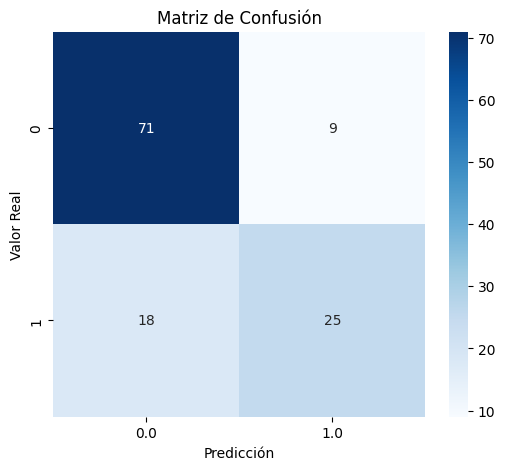

In [30]:
# Visualización de matriz de confusión con seaborn
cm_data = predictions.groupBy("diabetes_num", "prediction").count().toPandas()
cm_pivot = cm_data.pivot(index="diabetes_num", columns="prediction", values="count").fillna(0)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_pivot, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

El modelo ha obtenido un AUC-ROC de 0.8622, lo que indica que tiene un 86.2% de probabilidad de distinguir correctamente entre un paciente con diabetes y uno sin ella, lo que se considera un rendimiento aceptable. La exactitud global es del 78.05%, es decir, casi ocho de cada diez predicciones son correctas. La precisión alcanza el 73.53%, lo que significa que cuando el modelo predice diabetes, acierta en aproximadamente tres de cada cuatro casos.

Sin embargo, la métrica más preocupante es el recall o sensibilidad, que solo alcanza el 58.14%. Esto significa que el modelo es incapaz de detectar casi la mitad de los casos reales de diabetes (18 falsos negativos frente a 25 verdaderos positivos). En un contexto médico, los falsos negativos son especialmente graves porque implican no diagnosticar a un paciente que realmente tiene la enfermedad, lo que podría retrasar su tratamiento. El F1-Score de 0.6494 refleja este desequilibrio entre precisión y sensibilidad.

## 5. Reflexión y discusión

El modelo desarrollado demuestra que el machine learning puede ser una herramienta útil para la detección temprana de diabetes, aunque con limitaciones importantes. La glucosa en sangre se confirma como el factor más predictivo, seguido del IMC y la edad, lo que coincide con el conocimiento médico actual. Sin embargo, la baja sensibilidad del modelo (58.14%) indica que aún no es fiable como herramienta de diagnóstico única en un entorno clínico real.

**¿Cómo podríamos mejorar el modelo?** Para aumentar la sensibilidad y reducir los falsos negativos, se podría balancear el dataset mediante técnicas como SMOTE (sobre muestreo de la clase minoritaria) o ajustar el umbral de clasificación por debajo de 0.5 para priorizar la detección de casos positivos. También sería recomendable tratar los valores 0 como datos faltantes (imputándolos con la media o mediana) en lugar de considerarlos como valores reales.

**¿Qué otras técnicas de machine learning podríamos probar?** Además de la regresión logística, se podrían implementar Random Forest (robusto frente a datos desbalanceados), Gradient Boosted Trees (mayor precisión) o XGBoost (alto rendimiento en problemas médicos). Estas técnicas suelen manejar mejor las relaciones no lineales entre variables.

**¿Cómo este modelo puede ayudar en la detección temprana de enfermedades?** A pesar de sus limitaciones, el modelo puede utilizarse como sistema de apoyo al diagnóstico, identificando pacientes de alto riesgo que requieran pruebas adicionales. Esto permitiría priorizar recursos médicos en poblaciones con recursos limitados, agilizando la detección de casos sospechosos. No obstante, siempre debe ser supervisado por personal médico, respetando los límites éticos del machine learning en salud: el modelo no reemplaza el juicio clínico ni debe tomar decisiones autónomas sobre tratamientos.